For this task, ill be attempting to implement basic arithmetic circuits through qiskit.
A sum of a and b can be simplified into a XOR b
its carry can be placed into a AND B

# Half-Adder

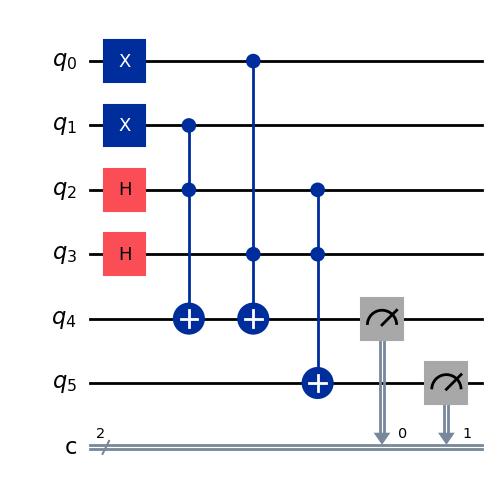

In [ ]:
from qiskit import QuantumCircuit
# from qiskit.primitives import StatevectorSampler
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import CCXGate, XGate, HGate
from qiskit.primitives import StatevectorSampler


sampler = StatevectorSampler()
#qiskit initializes qbits to |0>
#x gates flip the qbit, so its good for making them |1> states
#qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
qr = QuantumRegister(6,"q")
cr = ClassicalRegister(2,"c")

qc = QuantumCircuit(qr, cr, name='adder circuit')
#q2 and q3 should my opperands

#add randomness
qc.append(HGate(), [2])
qc.append(HGate(), [3])


qc.append(XGate(), [0])
qc.append(XGate(), [1])
# qc.append(CCXGate(), [0,1,2])
# qc.append(CCXGate(), [0,1,3])

#XOR (sum):

qc.append(CCXGate(), [1,2,4])
qc.append(CCXGate(), [0,3,4])


#AND (carry):
qc.append(CCXGate(), [2,3,5])

#make sure its all reversable

# qc.append(CCXGate(), [1,2,4])

# qc.append(CCXGate(), [0,1,3])
# qc.append(CCXGate(), [0,1,2])



#this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
#q5 should hold my result
#xor opperation for the carry: q4 contains 
# qc.append(CCXGate(), [1,2,3])
qc.measure(4,0)
#carry
qc.measure(5,1)
#          ^ indicates what qubit is being meassured
#            ^ indicates in what classical register is the meassurement being depoosited in

qc.draw("mpl")

To specify what values we are going to add, we are going to have to flip them. For example: For 0 + 1, we would have to flip q3 with an xgate. Perhaps this can be achived with an if statement and function arguments. 

In [171]:

# qc.measure_all()
result = sampler.run([qc], shots=1024).result()
print(result[0].data)
# print(dir(result[0].data.c6.get_counts()))

DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>))


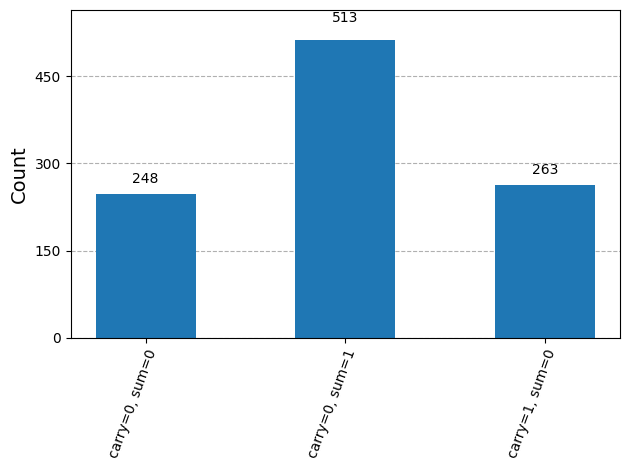

In [172]:
counts = result[0].data.c.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    # "carry=1, sum=1": counts.get("11", 0),
}

plot_histogram(pretty_counts)

The above histogram represents the distribution found in the half-adder's truth table

00: 1/4

01: 1/2

10: 1/4


# One bit Full-Adder

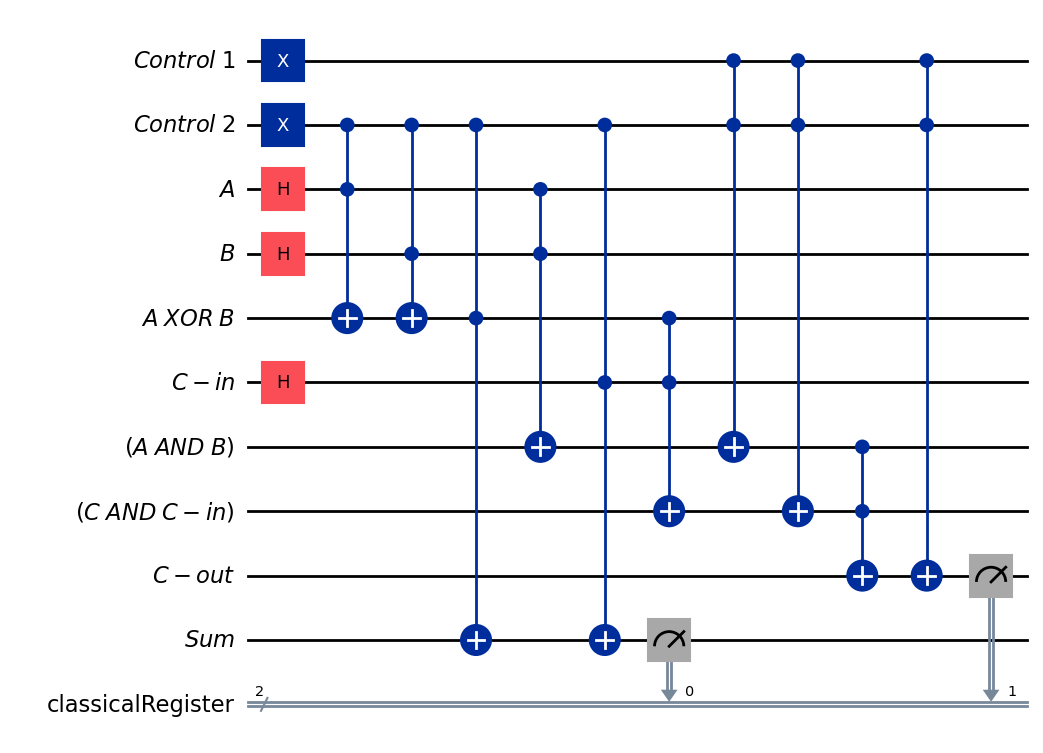

In [ ]:
def oneBitFullAdder(number1 = None, number2 = None):
    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display





        

    # sampler = StatevectorSampler()
    #qiskit initializes qbits to |0>
    #x gates flip the qbit, so its good for making them |1> states
    #qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A")
    qr3 = QuantumRegister(1,"B")
    qr4 = QuantumRegister(1,"A XOR B")
    qr5 = QuantumRegister(1,"C-in")
    qr6 = QuantumRegister(1,"(A AND B)")
    qr7 = QuantumRegister(1,"(C AND C-in)")
    qr8 = QuantumRegister(1,"C-out")
    qr9 = QuantumRegister(1,"Sum")


    cr = ClassicalRegister(2,"classicalRegister")

    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, cr, name='Full-adder circuit')

    #add randomness


    #order:
    Control1 = 0
    Control2 = 1
    A = 2
    B = 3
    C = 4
    C_in = 5
    aANDb = 6
    cANDc_in = 7
    C_out = 8
    SUM = 9

    if(number1 is None and number2 is None):
        qc.append(HGate(), [A])
        qc.append(HGate(), [B])
        qc.append(HGate(), [C_in])
    else:
        if(number1 > 1 or number1 < 0 or number2 > 1 or number2 < 0):
            print("Numbers to be added must both be either 1 or 0")
            return None
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        if(binary1 == "1"):
            qc.append(XGate(), [A])
        if(binary2 == "1"):
            qc.append(XGate(), [B])



    #set the control bit to |1>
    qc.append(XGate(), [Control1])
    qc.append(XGate(), [Control2])

    #set up the SUM
    #First XOR (sum):
    #XOR A and B to fill C
    qc.append(CCXGate(), [Control2,A,C])
    qc.append(CCXGate(), [Control2,B,C])

    #Perform XOR between C and C-in to get the sum
    qc.append(CCXGate(), [Control2,C,SUM])
    qc.append(CCXGate(), [Control2,C_in,SUM])

    #Sum is done

    #C-OUT

    #First, AND between A and B
    qc.append(CCXGate(),[A,B,aANDb])

    #Then, AND between C and C-IN
    qc.append(CCXGate(),[C,C_in,cANDc_in])


    #Finally, OR both of the opperated qbits
    #Invert both
    # NOT(A and B)
    qc.append(CCXGate(),[Control1,Control2,aANDb])
    # NOT(C and C-in)
    qc.append(CCXGate(),[Control1,Control2,cANDc_in])

    #Apply DEmorgan (AND (NOT(A and B) and (NOT(C and C-in)) and get the C-Out

    qc.append(CCXGate(),[aANDb,cANDc_in,C_out])

    #Apply the final inversion of de morgan:

    qc.append(CCXGate(),[Control1,Control2,C_out])


    # #Reverse the opperation due to entanglement:
    # qc.append(CCXGate(), [1,3,4])
    # qc.append(CCXGate(), [1,2,4])







    #this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
    #q5 should hold my result

    #xor opperation for the carry: q4 contains 
    #get the SUM first
    qc.measure(SUM,0)
    # Then the carry-out
    qc.measure(C_out,1)


    display(qc.draw("mpl"))
    return qc
qc = oneBitFullAdder()

# Optimization

In [2]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_kingston"
service = QiskitRuntimeService()
print(dir(service))
backend = service.backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=0)
print("Transpiled and got the backend")


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_account', '_active_api_client', '_all_instances', '_api_clients', '_backend_configs', '_backend_instance_groups', '_backends_list', '_channel', '_check_api_version', '_check_instance_usage', '_client_params', '_create_backend_obj', '_create_new_cloud_api_client', '_decode_job', '_default_instance', '_discover_account', '_discover_backends_from_instance', '_filter_instances_by_saved_preferences', '_get_api_client', '_get_api_clients', '_get_crn_from_instance_name', '_get_or_create_cloud_client', '_plans_preference', '_region', '_resolve_cloud_instances', '_run', '_saved_instances', '_tag

# Execute on hardware

In [26]:
# from qiskit_ibm_runtime import Sampler


# sampler = Sampler(mode=backend)

# job = sampler.run([qc_transpiled])

# print(dir(job))

# print(f"job_id: {job.id()}")



['ERROR', 'JOB_FINAL_STATES', '__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_api_client', '_backend', '_creation_date', '_empty_result_queue', '_error_message', '_error_msg_from_job_response', '_executor', '_final_result_decoder', '_image', '_job_id', '_private', '_program_id', '_queue_info', '_reason', '_reason_code', '_service', '_session_id', '_set_error_message', '_set_status', '_set_status_and_error_message', '_status', '_status_from_job_response', '_tags', '_usage_estimation', '_version', 'backend', 'cancel', 'cancelled', 'creation_date', 'done', 'error_message', 'errored', 'image', 'in_final_state', 'inputs', 'instance', 'job_id', 'logs', 'metadata', 'metrics', 'primitive_id', 'private', 'properties', 'result', 'running', 'session_id', 'status', 'tags', 'update_tags', 'usage', 'usage_estimation', 'wait_for_final_state']


In [15]:
print(job.job_id())

d7tpvc7ljm6s73bcvim0


# Hardware

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



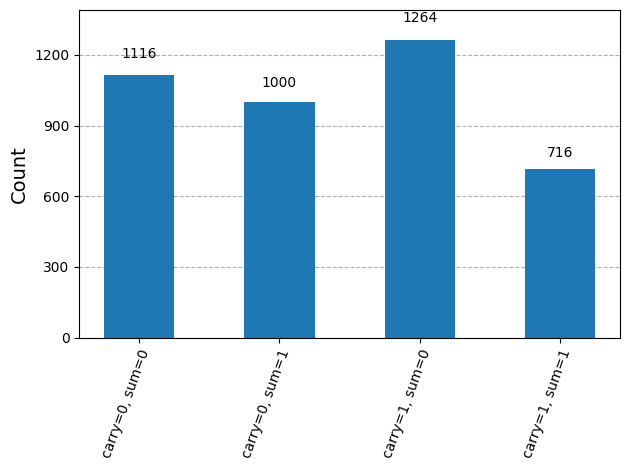

In [31]:
result = job.result()
print(result[0].data, "\n")
Real_counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": Real_counts.get("00", 0),
    "carry=0, sum=1": Real_counts.get("01", 0),
    "carry=1, sum=0": Real_counts.get("10", 0),
    "carry=1, sum=1": Real_counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}

display(plot_histogram(pretty_counts))

# Simulation

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



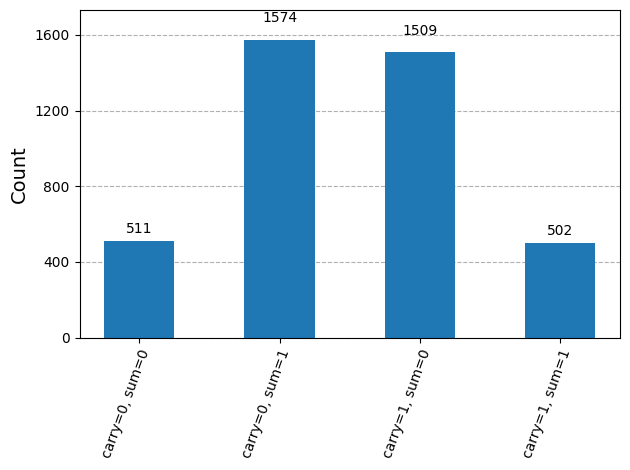

In [32]:
samplerSim = StatevectorSampler()

result = samplerSim.run([qc], shots=(1024*4)).result()
print(result[0].data, "\n")
counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    "carry=1, sum=1": counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}

display(plot_histogram(pretty_counts))

The above histogram represents the distribution found in the full adder's truth table

00: 1/8

10: 3/8

01: 3/8

11: 1/8

# Metrics:
## Simulated Circuit depth vs transpiled circuit's depth

In [ ]:
#
print(f"og circuit's depth: {qc.depth()}")
print(f"transpiled circuit's depth: {qc_transpiled.depth()}")

og circuit's depth: 10
transpiled circuit's depth: 513


#  Error rate

In [43]:
print("Percent error for Carry = 0 and Sum = 0")
num = (abs((counts["00"] - Real_counts["00"] ) / Real_counts["00"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 0 and Sum = 1")
num = (abs((counts["01"] - Real_counts["01"] ) / Real_counts["01"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 1 and Sum = 0")
num = (abs((counts["10"] - Real_counts["10"] ) / Real_counts["10"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 1 and Sum = 1")
num = (abs((counts["11"] - Real_counts["11"] ) / Real_counts["11"])) * 100
print(f"{round(num,2)}%\n")

Percent error for Carry = 0 and Sum = 0
54.21%

Percent error for Carry = 0 and Sum = 1
57.4%

Percent error for Carry = 1 and Sum = 0
19.38%

Percent error for Carry = 1 and Sum = 1
29.89%



# T-depth

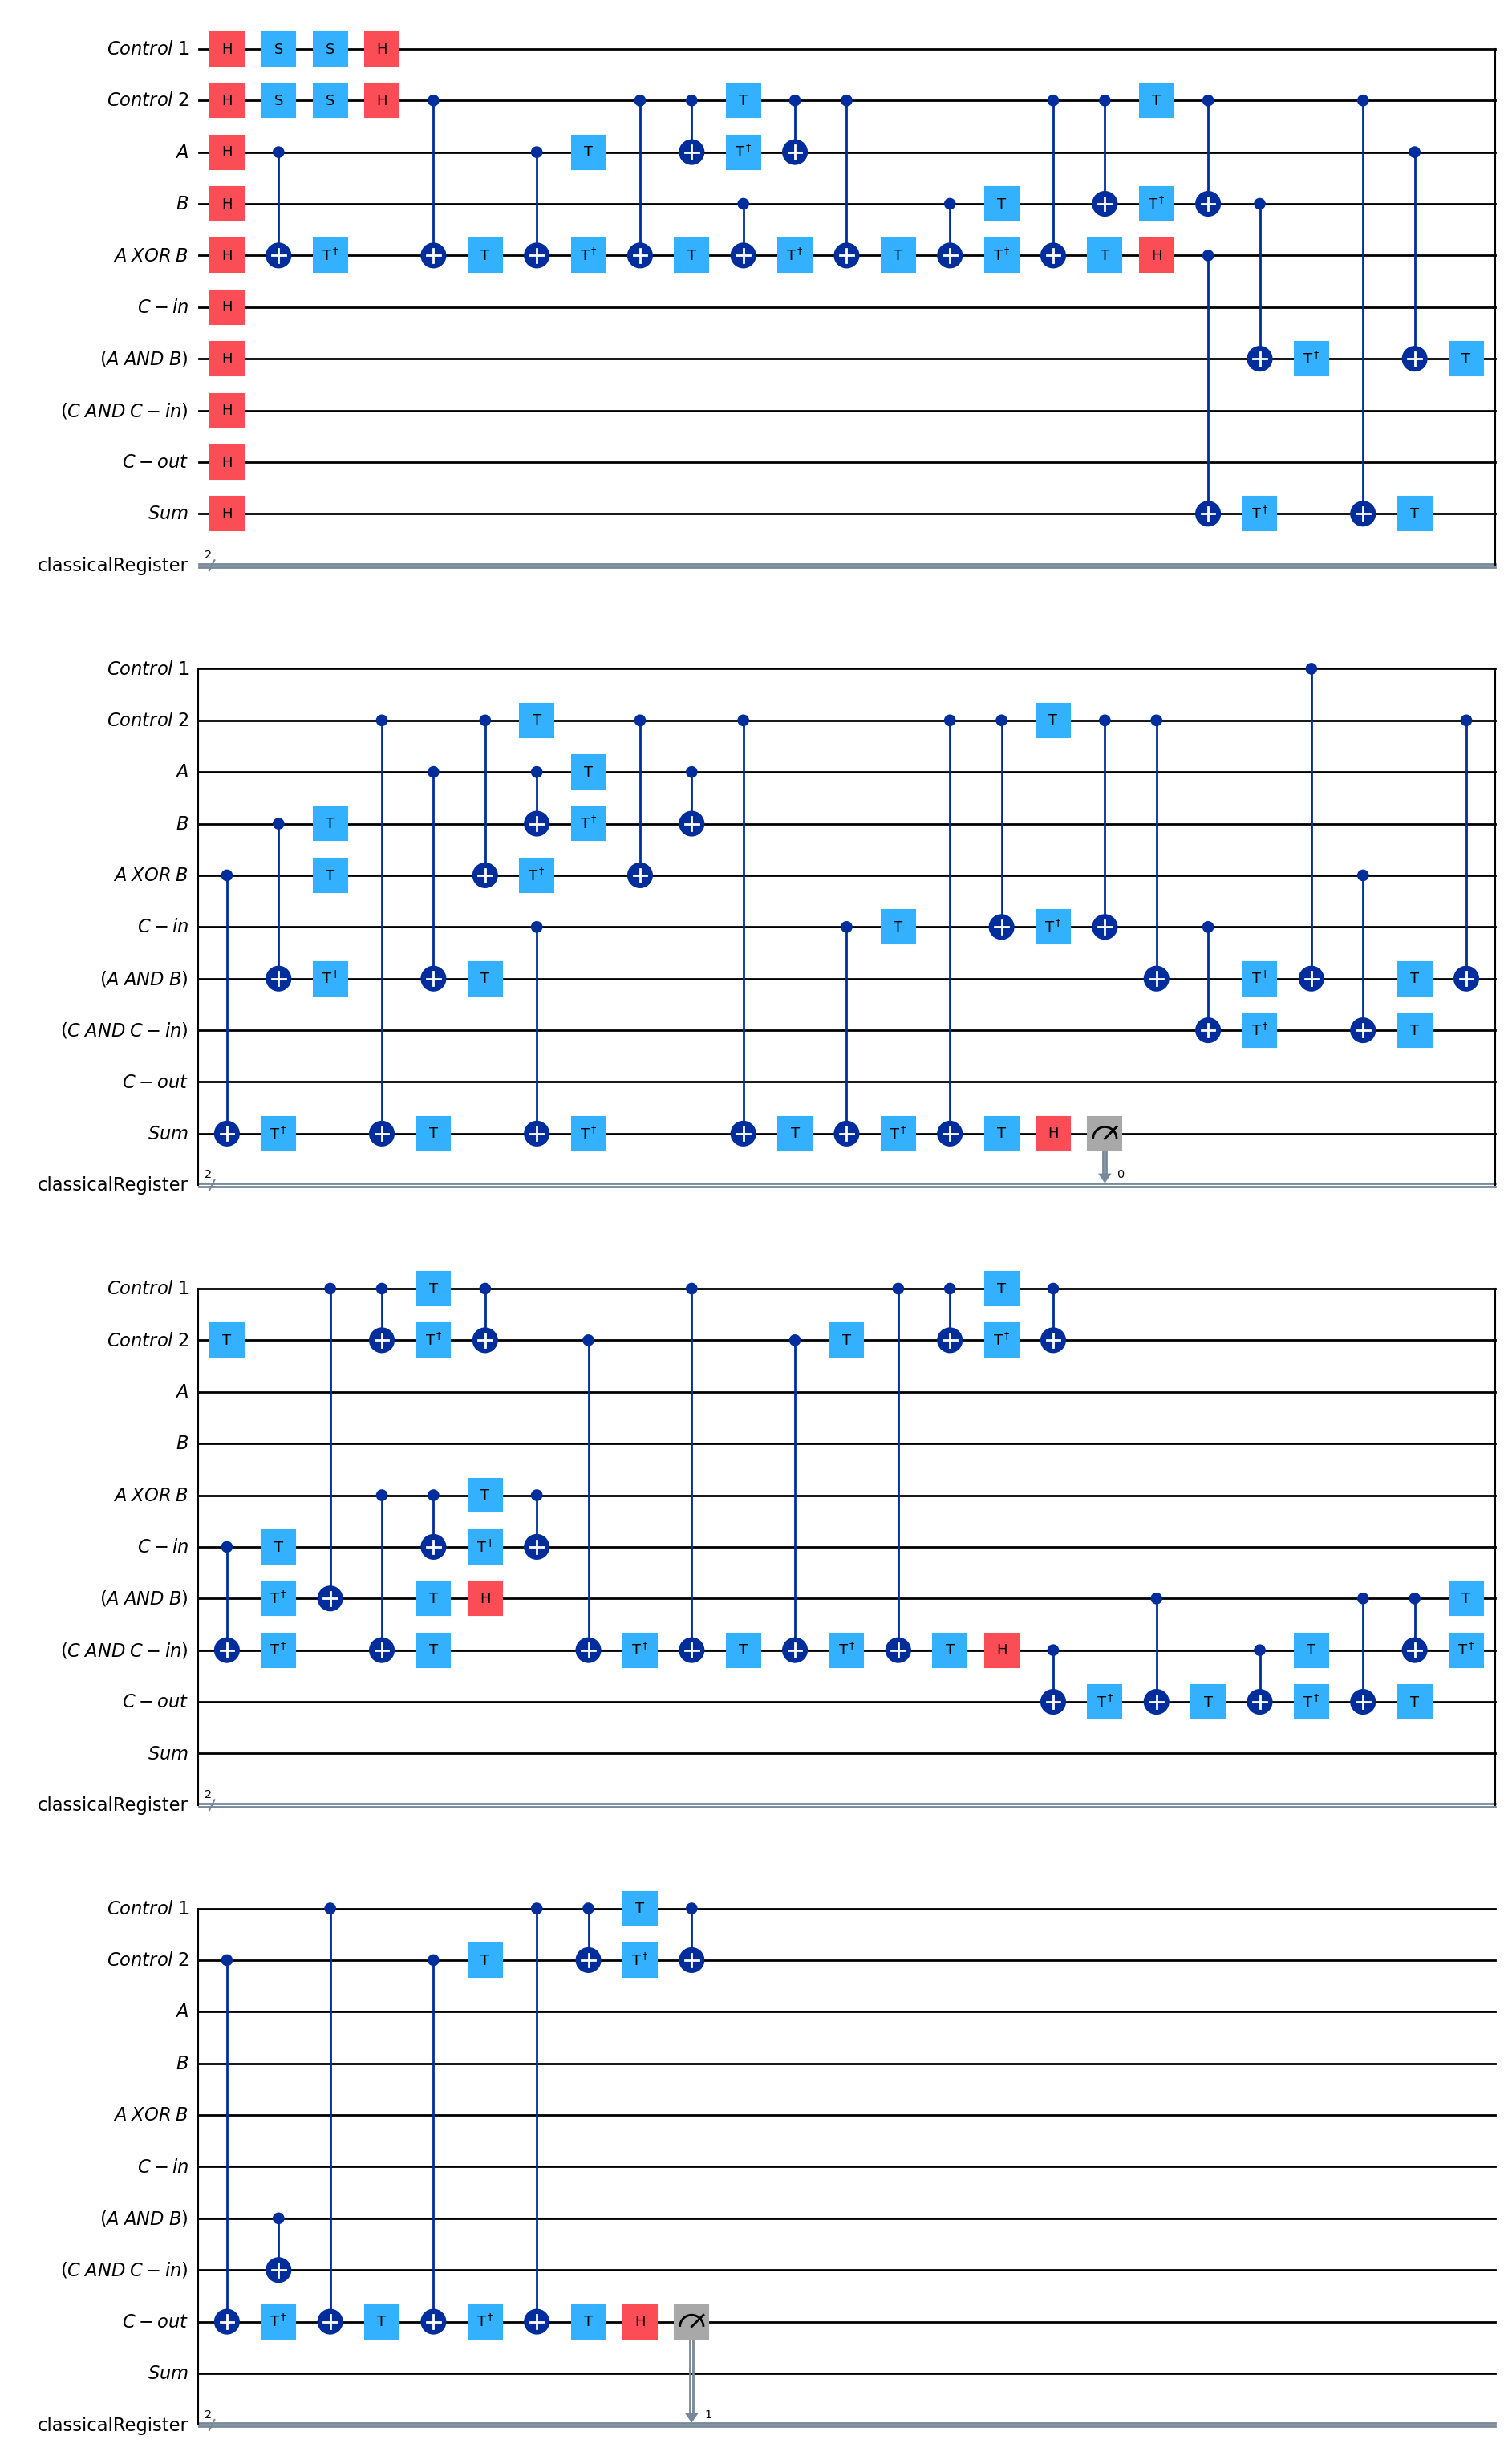

In [52]:
from qiskit import transpile

decomposed = transpile(qc, basis_gates=['cx', 'h', 't', 'tdg', 's', 'sdg'])
    
decomposed.draw("mpl")


In [53]:
print(decomposed.count_ops())

OrderedDict({'cx': 60, 't': 40, 'tdg': 30, 'h': 17, 's': 4, 'measure': 2})


In [54]:
from qiskit.converters import circuit_to_dag

dag = circuit_to_dag(decomposed)

t_depth = 0
for layer in dag.layers():
    if any(node.name in ['t', 'tdg'] for node in layer['graph'].op_nodes()):
        t_depth += 1

print("T-depth:", t_depth)

T-depth: 43


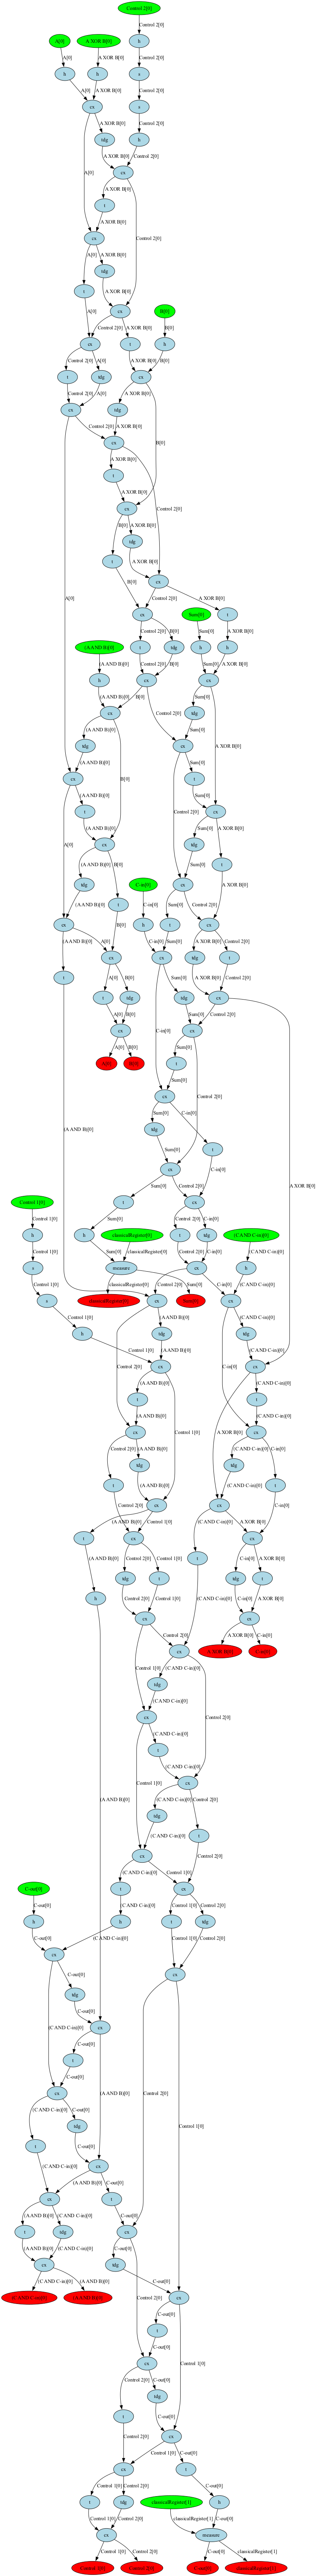

In [58]:
dag.draw()

# Testing survival of inputed operations
## If i were to give the circuit "0 + 0", then all the results should point to the bitstring "00" as sum is 0 and carry is 0:

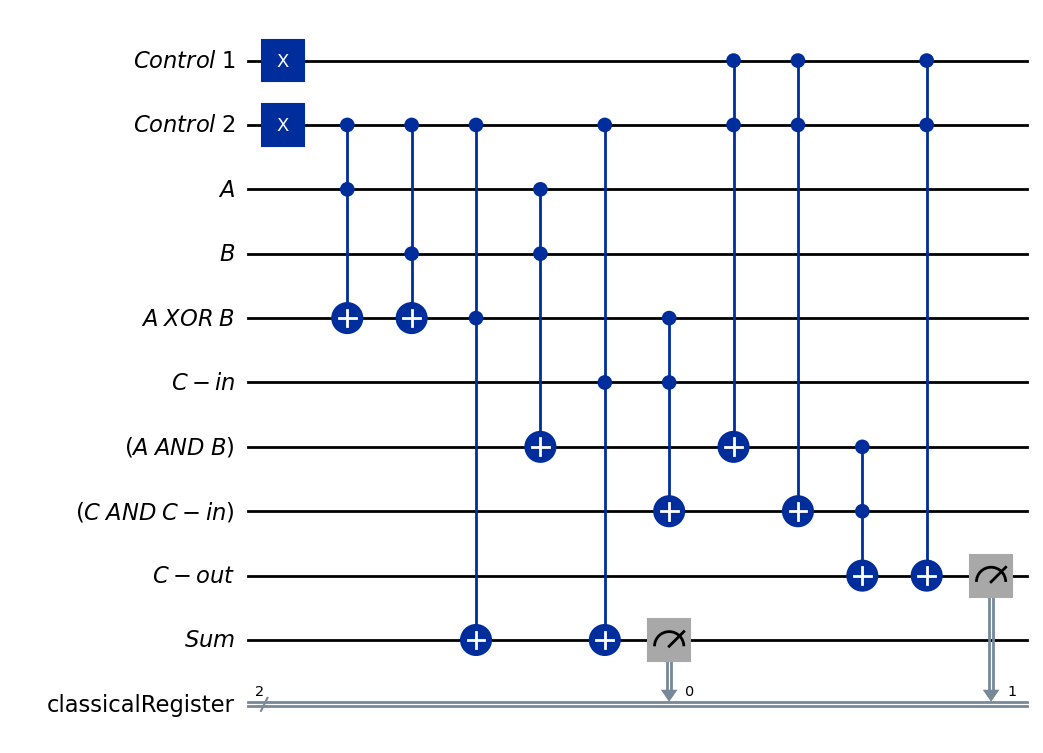

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



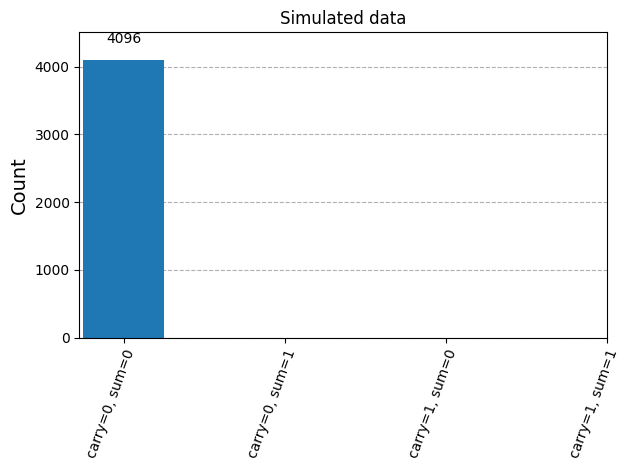

In [84]:
qc = oneBitFullAdder(0,0)
samplerSim = StatevectorSampler()

result = samplerSim.run([qc], shots=(1024*4)).result()
print(result[0].data, "\n")
counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    "carry=1, sum=1": counts.get("11", 0),

}
SimHisto = plot_histogram(pretty_counts, title="Simulated data")
display(SimHisto)

The above assumption was proven to be true.

Now, we try to do the same on real hardware, where results shouldn't be so "perfect". We shall call this the "Survivability test"

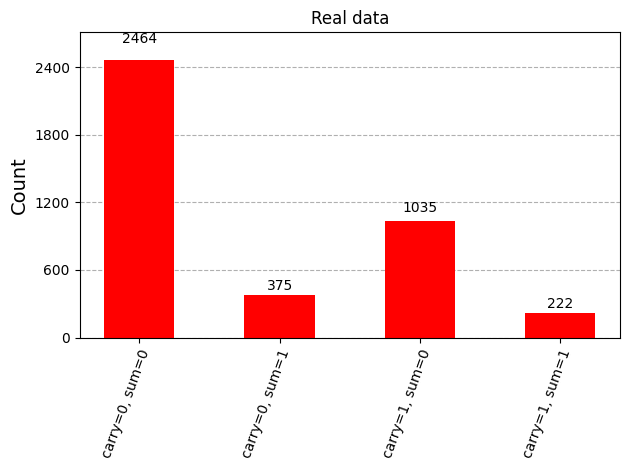

In [ ]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_kingston"
service = QiskitRuntimeService()
print(dir(service))
backend = service.backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=0)
print("Transpiled and got the backend")

from qiskit_ibm_runtime import Sampler


sampler = Sampler(mode=backend)

job = sampler.run([qc_transpiled])

# # print(dir(job))

# print(f"job_id: {job.job_id()}\n")

result = job.result()
# print(result[0].data, "\n")
Real_counts = result[0].data.classicalRegister.get_counts()
real_pretty_counts = {
    "carry=0, sum=0": Real_counts.get("00", 0),
    "carry=0, sum=1": Real_counts.get("01", 0),
    "carry=1, sum=0": Real_counts.get("10", 0),
    "carry=1, sum=1": Real_counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}
RealHisto = plot_histogram(real_pretty_counts, title="Real data", color='red')
display(RealHisto)

# Calculate the error rate

In [93]:
addedWrongVals = Real_counts["01"] + Real_counts["10"] + Real_counts["11"]

error = round((addedWrongVals/4096) * 100,2)
print(f"Rate of faulty results: {error}%")

Rate of faulty results: 39.84%


## Compare both results

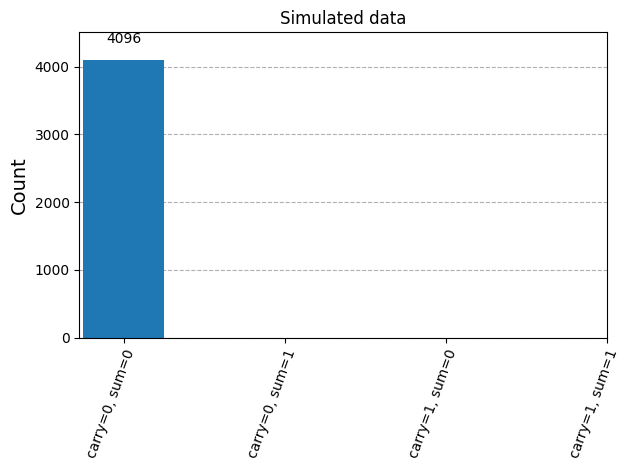

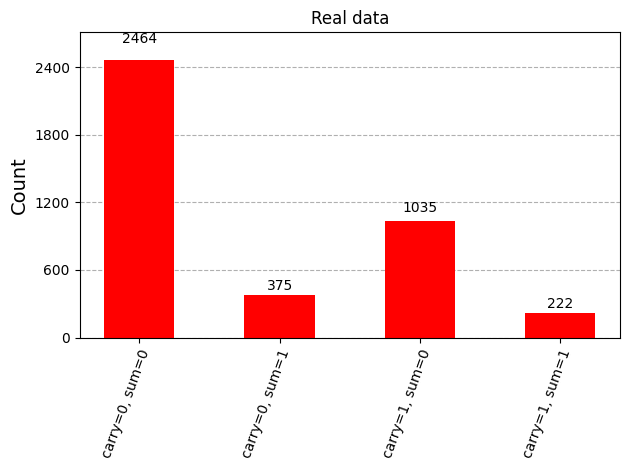

In [85]:
display(SimHisto)
display(RealHisto)

# Addition of 4 bit numbers using 3 full adders and 1 half adder

Idea: Turn the above full adder into a function and use it to individually add the numbers via a loop (maybe), while sharing the same classical register

test
first operand 0011 and second operand 0010



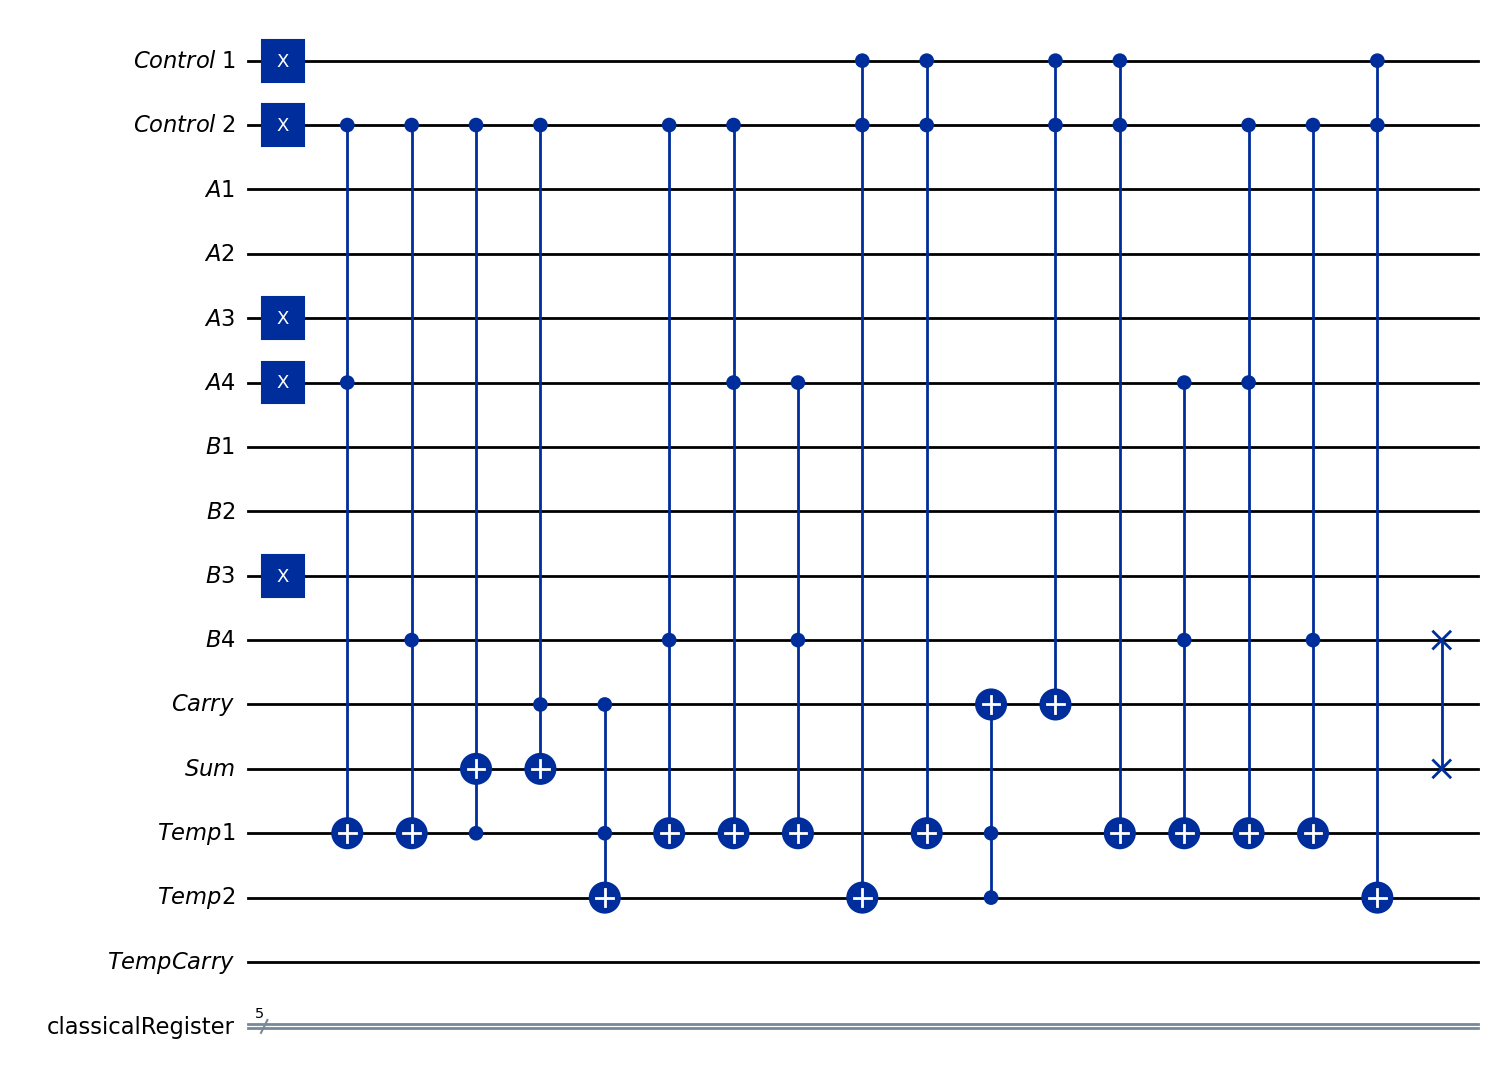

In [ ]:
def FourBitQuantumAdder(number1 = None, number2 = None):

    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    print("test")
    sampler = StatevectorSampler()
    list_of_results = []
    if(number1 != None and number2 != None):
        cr = ClassicalRegister(5,"classicalRegister")
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]

        if(len(binary1) != 4):
            length = 4 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 4):
            length = 4 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        print(f"first operand {binary1} and second operand {binary2}\n")
        carryOut = 0
        #since these operations are from right to left, we iterate backwards:
        
        
        qr0 = QuantumRegister(1,"Control 1")
        qr1 = QuantumRegister(1,"Control 2")
        qr2 = QuantumRegister(1,"A1")
        qr3 = QuantumRegister(1,"A2")
        qr4 = QuantumRegister(1,"A3")
        qr5 = QuantumRegister(1,"A4")

        qr6 = QuantumRegister(1,"B1")
        qr7 = QuantumRegister(1,"B2")
        qr8 = QuantumRegister(1,"B3")
        qr9 = QuantumRegister(1,"B4")
        qr10 = QuantumRegister(1,"Carry")
        qr11 = QuantumRegister(1,"Sum")
        qr12 = QuantumRegister(1,"Temp1")
        qr13 = QuantumRegister(1,"Temp2")
        qr14 = QuantumRegister(1,"TempCarry")

        qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, qr14, cr, name='Full-adder circuit')

        
        #read the input and set the 
        #appropiate qbits to |1>
        count = 2
        for x in range(0,4):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        control_1 = 0
        control_2 = 1
        A1 = 2
        A2 = 3
        A3 = 4
        A4 = 5
        B1 = 6
        B2 = 7
        B3 = 8
        B4 = 9
        Carry = 10
        Sum = 11
        Temp1 = 12
        Temp2 = 13



        #set the control bit to |1>
        qc.append(XGate(), [control_1])
        qc.append(XGate(), [control_2])

        #set up the SUM of the LSBs (least signigicant bits)
        #First XOR (sum):
        #XOR A4 and B4 to fill T1
        qc.append(CCXGate(), [control_2,A4,Temp1])
        qc.append(CCXGate(), [control_2,B4,Temp1])

        #Perform XOR between the T1 and the carry to get the sum
            #Xor with T1
        qc.append(CCXGate(), [control_2,Temp1,Sum])




            #Xor with carry ****
        qc.append(CCXGate(), [control_2,Carry,Sum])



        #Sum between A4 and B4 is done



        #Carry for A4 and B4
            #AND between T1 and C-IN dumped into T2 ****
        qc.append(CCXGate(),[Carry,Temp1,Temp2])




            #now we clean T1 from the A4 XOR B4 operation
        qc.append(CCXGate(), [control_2,B4,Temp1])
        qc.append(CCXGate(), [control_2,A4,Temp1])

            #AND between A4 and B4 into T1
        qc.append(CCXGate(),[A4,B4,Temp1])

        #OR T1 and T2:
            #First, Not(T2)
        qc.append(CCXGate(), [control_1,control_2,Temp2])
            #Second, Not(T1)
        qc.append(CCXGate(), [control_1, control_2, Temp1])
        #And both T1 and T2 into carry bit
        qc.append(CCXGate(), [Temp1, Temp2, Carry])
        #Finally, invert carry bit
        qc.append(CCXGate(), [control_1, control_2, Carry])

        #Or finished and Carry computed, clean T1 and T2
        # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

        #reverse the NOT and AND
            #the NOT
        qc.append(CCXGate(), [control_1, control_2, Temp1])

            #the and
        qc.append(CCXGate(), [A4, B4, Temp1])

        #T1 should be back into its OG state, so now we recompute A XOR B
        qc.append(CCXGate(), [control_2,A4,Temp1])
        qc.append(CCXGate(), [control_2,B4,Temp1])

        #undo NOT T2
        qc.append(CCXGate(), [control_1,control_2,Temp2])

        #UNDO T1


        #and now we have the instruments to undo T2's operation




        

       # Now we are done
        # qc.append(XGate(), [12])

        #Swap the result in Sum into B4 and reset Sum
            #Swap SUM and B4
        qc.swap(Sum, B4)
            #Reset SUM
        # qc.append(Reset(), [11])
        

        #Now repeat for all qbits


#--------------A3 and B3--------------------------

    #-------------------------------------------
        # #now we can meassure carry and Sum
        #carry
        # qc.measure(10,0)
        # #and sum
        # qc.measure(9,4)
        # qc.measure(8,3)
        # qc.measure(7,2)
        # qc.measure(6,1)
        

        display(qc.draw("mpl"))




        # result = sampler.run([qc], shots=(30 * 1024)).result()
        # print(result[0].data, "\n")
        # counts = result[0].data.classicalRegister.get_counts()
        # display(plot_histogram(counts))
        # print(list(counts.keys()))
        # if(keys[0][0] == 1):
        #     carryOut = 1
        # else:
        #     carryOut = 0
        # print(f"\n i {list_of_results}")








#--------------------------
    else:
        print("No values inserted\n")
        cr = ClassicalRegister(5,"classicalRegister")
        # binary1 = bin(number1)[2:]
        # binary2 = bin(number2)[2:]

        # if(len(binary1) != 4):
        #     length = 4 - len(binary1)
        #     buff = ""
        #     for x in range(0, (length)):
        #         buff += "0"
        #     binary1 = buff + binary1
        # if(len(binary2) != 4):
        #     length = 4 - len(binary2)
        #     buff = ""
        #     for x in range(0, (length)):
        #         buff += "0"
        #     binary2 = buff + binary2
        # print(f"first operand {binary1} and second operand {binary2}\n")
        # carryOut = 0
        #since these operations are from right to left, we iterate backwards:
        
        
        qr0 = QuantumRegister(1,"Control 1")
        qr1 = QuantumRegister(1,"Control 2")
        qr2 = QuantumRegister(1,"A1")
        qr3 = QuantumRegister(1,"A2")
        qr4 = QuantumRegister(1,"A3")
        qr5 = QuantumRegister(1,"A4")

        qr6 = QuantumRegister(1,"B1")
        qr7 = QuantumRegister(1,"B2")
        qr8 = QuantumRegister(1,"B3")
        qr9 = QuantumRegister(1,"B4")
        qr10 = QuantumRegister(1,"Carry")
        qr11 = QuantumRegister(1,"Sum")
        qr12 = QuantumRegister(1,"Temp1")
        qr13 = QuantumRegister(1,"Temp2")

        qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, cr, name='Full-adder circuit')

        
        #read the input and set the 
        #appropiate qbits to |1>
        # count = 2
        # for x in range(0,4):
        #     if(binary1[x] == "1"):
        #         qc.append(XGate(), [count])
        #     count += 1

        # count = 6
        # for x in range(0,4):
        #     if(binary2[x] == "1"):
        #         qc.append(XGate(), [count])
        #     count += 1

        qc.append(HGate(), [2])
        qc.append(HGate(), [3])
        qc.append(HGate(), [4])
        qc.append(HGate(), [5])

        qc.append(HGate(), [6])
        qc.append(HGate(), [7])
        qc.append(HGate(), [8])
        qc.append(HGate(), [9])



        # 0 = Control 1
        # 1 = Control 2
        # 2 = A1
        # 3 = A2
        # 4 = A3
        # 5 = A4
        # 6 = B1
        # 7 = B2
        # 8 = B3
        # 9 = B4
        # 10 = Carry
        # 11 = Sum
        # 12 = Temp1
        # 13 = Temp2



        #set the control bit to |1>
        qc.append(XGate(), [0])
        qc.append(XGate(), [1])

        #set up the SUM of the LSBs (least signigicant bits)
        #First XOR (sum):
        #XOR A4 and B4 to fill T1
        qc.append(CCXGate(), [1,5,12])
        qc.append(CCXGate(), [1,9,12])

        #Perform XOR between the T1 and the carry to get the sum
            #Xor with T1
        qc.append(CCXGate(), [1,12,11])
            #Xor with carry
        qc.append(CCXGate(), [1,10,11])


        #Sum between A4 and B4 is done

        #Carry for A4 and B4


        #AND between T1 and C-IN dumped into T2
        qc.append(CCXGate(),[10,12,13])

        #now we clean T1
        qc.append(CCXGate(), [1,9,12])
        qc.append(CCXGate(), [1,5,12])

        #AND between A4 and B4 into T1
        qc.append(CCXGate(),[5,9,12])

        #or T1 and T2:
            #First, Not(T2)
        qc.append(CCXGate(), [0,1,13])
            #Second, Not(T1)
        qc.append(CCXGate(), [0, 1, 12])
        #And both T1 and T2 into carry bit
        qc.append(CCXGate(), [12, 13, 10])
        #Finally, invert carry bit
        qc.append(CCXGate(), [0, 1, 10])

        #Or finished and Carry computed, clean T1 and T2 
        qc.append(Reset(), [12])
        qc.append(Reset(), [13])

       # Now we are done
        # qc.append(XGate(), [12])

        #Swap the result in Sum into B4 and reset Sum
            #Swap SUM and B4
        qc.swap(11, 9)
            #Reset SUM
        qc.append(Reset(), [11])
        

        #Now repeat for all qbits


# #now we can meassure carry and Sum
        #carry
        # qc.measure(10,0)
        # #and sum
        # qc.measure(9,4)
        # qc.measure(8,3)
        # qc.measure(7,2)
        # qc.measure(6,1)
        

        display(qc.draw("mpl"))




        result = sampler.run([qc], shots=(1024)).result()
        print(result[0].data, "\n")
        counts = result[0].data.classicalRegister.get_counts()
        display(plot_histogram(counts))
        print(list(counts.keys()))
        # if(keys[0][0] == 1):
        #     carryOut = 1
        # else:
        #     carryOut = 0
        # print(f"\n i {list_of_results}")    return list_of_results
binaries = FourBitQuantumAdder(3,2)


In [177]:
print(bin(8)[2:])
print("001")

1000
001


In [178]:


for x in binaries:
    print(int(x,2))
